 Data Loaded
    Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ...      lat      long  \
0    Banks      F                561 Perry Cove  ...  36.0788  -81.1781   
1     Gill      F  43039 Riley Greens Suit

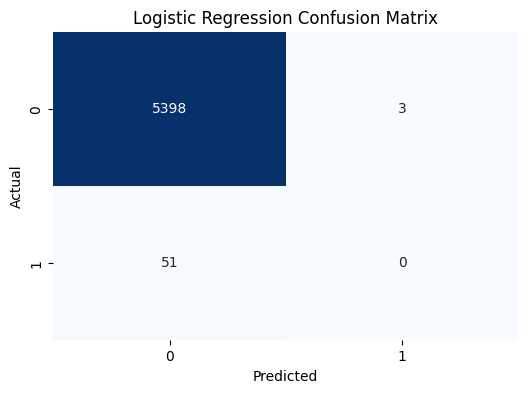


 Training Decision Tree...
Decision Tree Results:
Accuracy : 99.19%
Precision: 56.14%
Recall   : 62.75%
F1-Score : 59.26%

 Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5401
         1.0       0.56      0.63      0.59        51

    accuracy                           0.99      5452
   macro avg       0.78      0.81      0.79      5452
weighted avg       0.99      0.99      0.99      5452



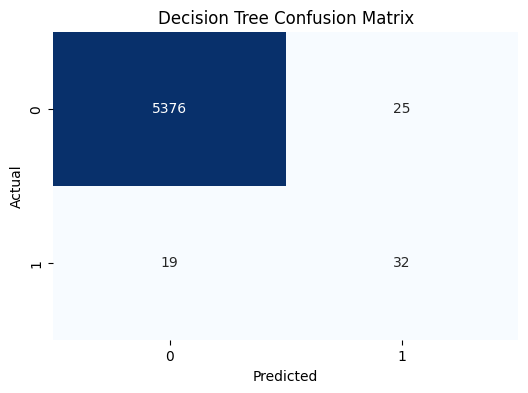


 Training Random Forest...
Random Forest Results:
Accuracy : 99.47%
Precision: 86.67%
Recall   : 50.98%
F1-Score : 64.20%

 Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5401
         1.0       0.87      0.51      0.64        51

    accuracy                           0.99      5452
   macro avg       0.93      0.75      0.82      5452
weighted avg       0.99      0.99      0.99      5452



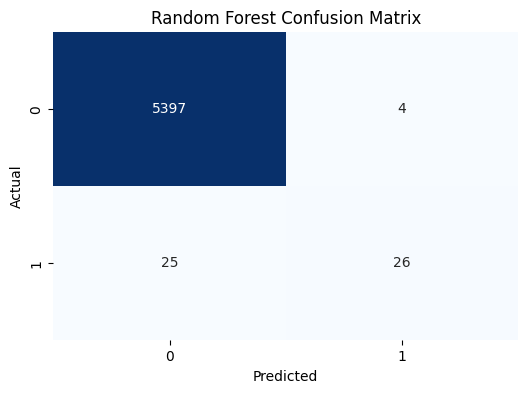

In [ ]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean data
data = pd.read_csv('/content/fraudTrain.csv')
print(" Data Loaded\n", data.head())

# Drop unnecessary columns
data.drop(['trans_date_trans_time', 'merchant', 'category', 'first', 'last', 'street', 'city',
           'state', 'zip', 'job', 'dob', 'unix_time', 'trans_num'], axis=1, inplace=True, errors='ignore')

# Encode gender
data['gender'] = data['gender'].map({'F': 0, 'M': 1})

# Features & target
X = data.drop('is_fraud', axis=1)
y = data['is_fraud']

# Remove rows with missing values in the target variable
data.dropna(subset=['is_fraud'], inplace=True)

# Features & target after dropping NaNs
X = data.drop('is_fraud', axis=1)
y = data['is_fraud']

# Scale features
X_scaled = StandardScaler().fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(" Data Preprocessing Complete")

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Train & Evaluate models
for name, model in models.items():
    print(f"\n Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    print(f"{name} Results:")
    print(f"Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")
    print(f"Precision: {precision_score(y_test, y_pred, zero_division=0)*100:.2f}%")
    print(f"Recall   : {recall_score(y_test, y_pred, zero_division=0)*100:.2f}%")
    print(f"F1-Score : {f1_score(y_test, y_pred, zero_division=0)*100:.2f}%")
    print("\n Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))

    # Confusion Matrix
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

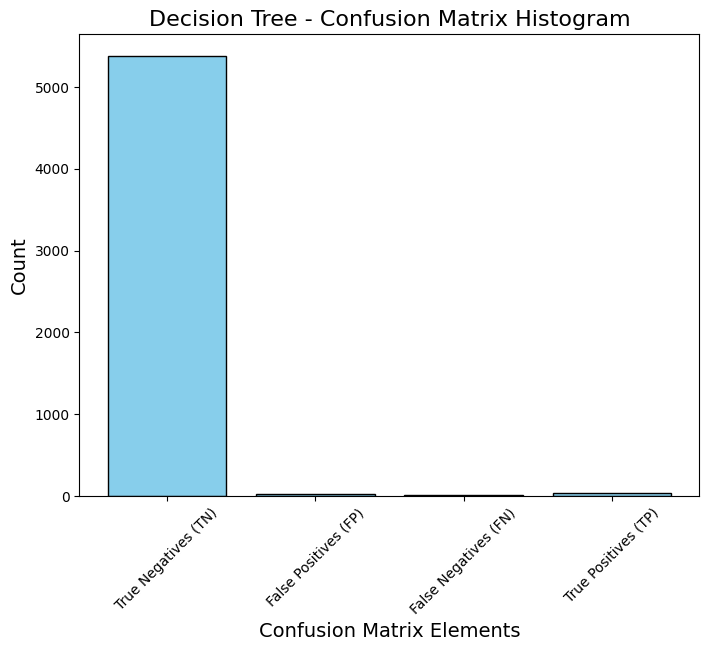

In [ ]:
dt_model = models['Decision Tree']
y_pred_dt = dt_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_dt)

# Flatten the matrix to get TN, FP, FN, TP
cm_values = cm.flatten()
labels = ['True Negatives (TN)', 'False Positives (FP)', 'False Negatives (FN)', 'True Positives (TP)']

# Plot Histogram (Bar Chart)
plt.figure(figsize=(8,6))
plt.bar(labels, cm_values, color='skyblue', edgecolor='black')
plt.title('Decision Tree - Confusion Matrix Histogram', fontsize=16)
plt.xlabel('Confusion Matrix Elements', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45)
plt.show()

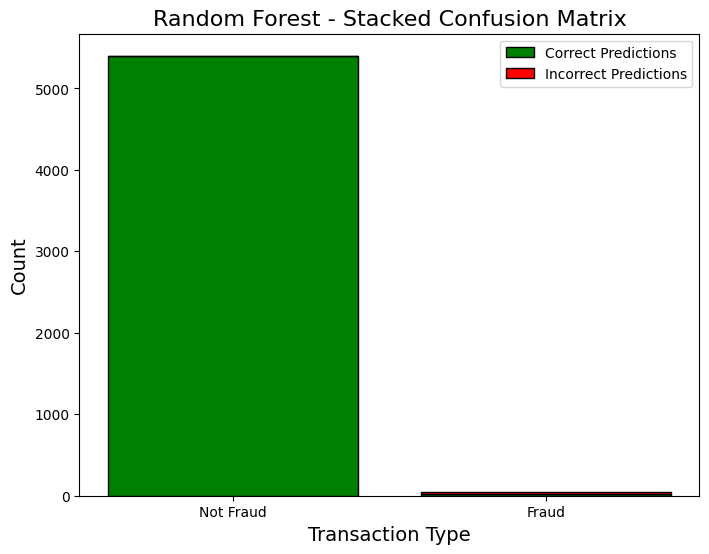

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Split values
tn, fp, fn, tp = cm.ravel()
categories = ['Not Fraud', 'Fraud']
true_values = [tn, tp]
false_values = [fp, fn]

# Stacked Bar Chart
plt.figure(figsize=(8,6))
plt.bar(categories, true_values, label='Correct Predictions', color='green', edgecolor='black')
plt.bar(categories, false_values, bottom=true_values, label='Incorrect Predictions', color='red', edgecolor='black')
plt.title('Random Forest - Stacked Confusion Matrix', fontsize=16)
plt.xlabel('Transaction Type', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend()
plt.show()


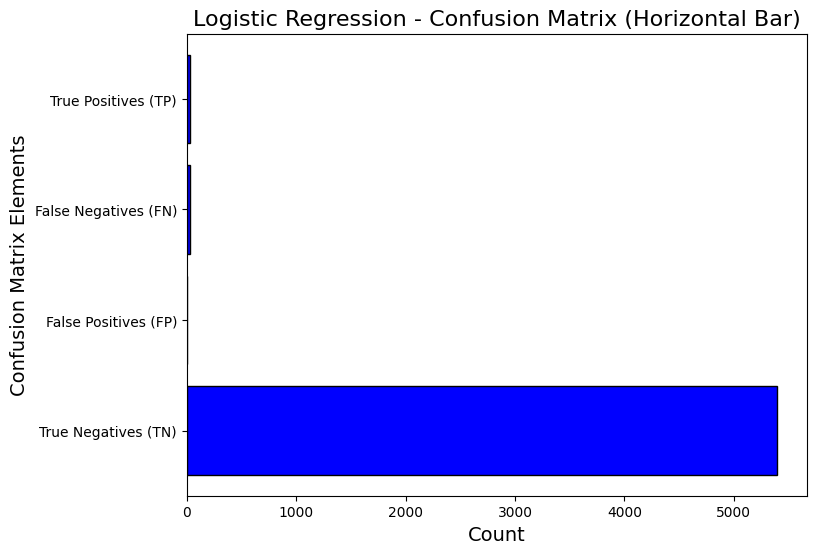

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_values = cm.flatten()
labels = ['True Negatives (TN)', 'False Positives (FP)', 'False Negatives (FN)', 'True Positives (TP)']

# Horizontal Bar Plot
plt.figure(figsize=(8,6))
plt.barh(labels, cm_values, color='blue', edgecolor='black')
plt.title('Logistic Regression - Confusion Matrix (Horizontal Bar)', fontsize=16)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Confusion Matrix Elements', fontsize=14)
plt.show()


In [ ]:
duplicate_indices_before = data.index.duplicated().sum()
print(duplicate_indices_before)

# Reset the index and drop the old index
data = data.reset_index(drop=True)

# Check for duplicated indices again
duplicate_indices_after = data.index.duplicated().sum()
print(duplicate_indices_after)

0
0


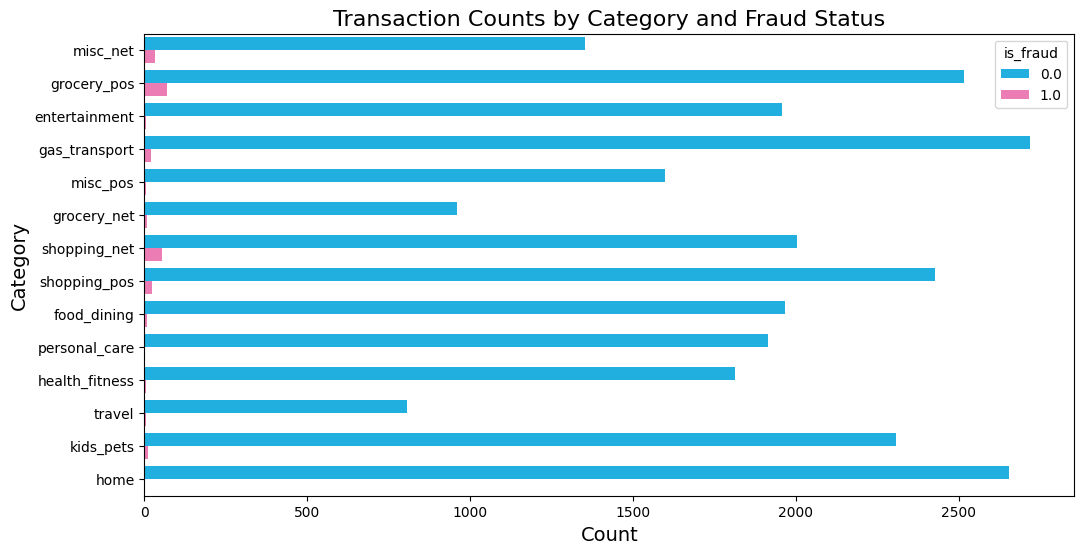

In [ ]:
# Load the data again specifically for plotting category counts
data_for_plotting = pd.read_csv('/content/fraudTrain.csv')

# Plot transaction counts by category and fraud status
plt.figure(figsize=(12, 6))

# Seaborn countplot
sns.countplot(data=data_for_plotting, y='category', hue='is_fraud', palette=['#00BFFF', '#FF69B4'])  # Blue for Not Fraud, Pink for Fraud

# Titles and labels
plt.title('Transaction Counts by Category and Fraud Status', fontsize=16)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Category', fontsize=14)

plt.show()